<a href="https://colab.research.google.com/github/jioring4351/hongong-ML-study/blob/main/Chapter8/8_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 합성곱 신경망의 시각화

## 가중치 시각화

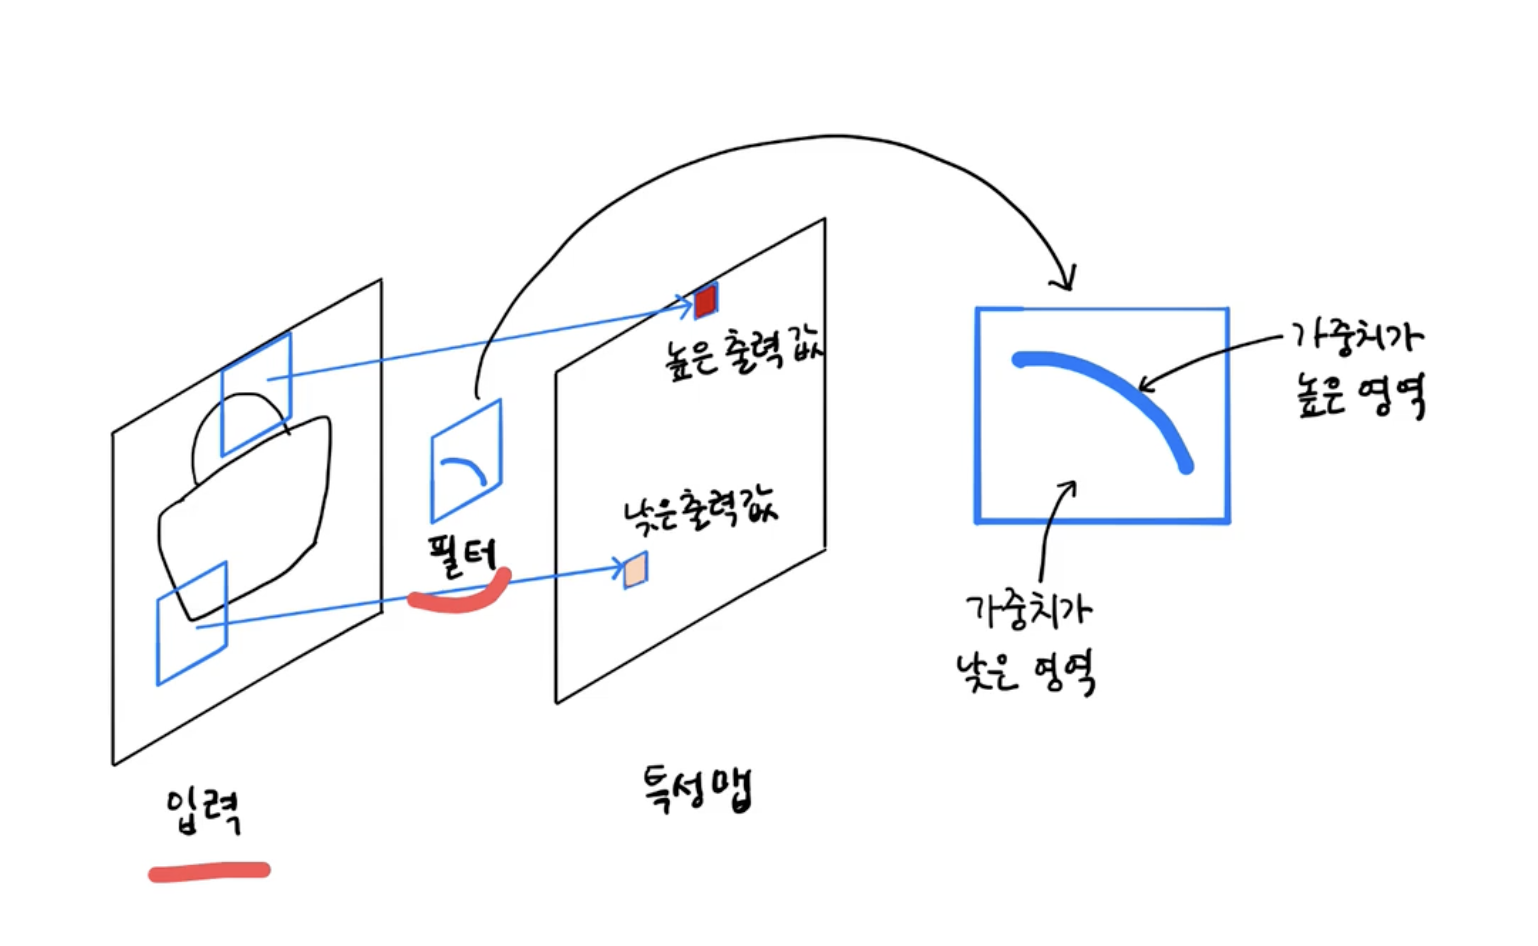

In [7]:
#2절에서 만든 모델을 사용
import keras
model = keras.models.load_model('best-cnn-model.keras')

In [8]:
#층 확인
model.layers

[<Conv2D name=conv2d, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

In [10]:
#합성곱 층의 가중치 조사(weights 속성)
conv = model.layers[0]
#첫 번째 원소는 가중치, 두 번째 원소는 절편
print(conv.weights[0].shape, conv.weights[1].shape)

(3, 3, 1, 32) (32,)


In [11]:
#weights 속성은 Tensor 클래스. 여기선 넘파이로 변환후 평균과 표준편차 계산
conv_weights = conv.weights[0].numpy()
print(conv_weights.mean(), conv_weights.std())

-0.017997514 0.23510416


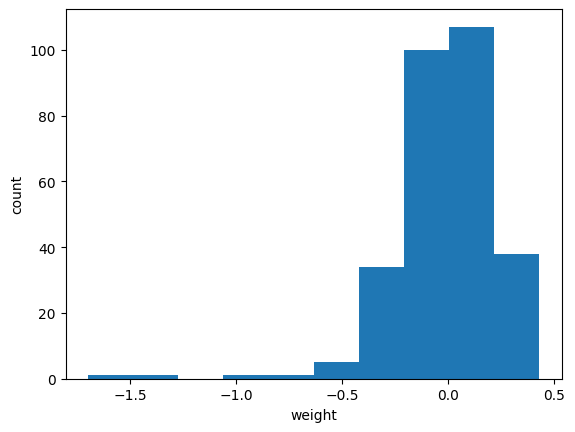

In [13]:
#가중치의 히스토그램 그려보기
import matplotlib.pyplot as plt

plt.hist(conv_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()
#종 모양의 분포

## 층의 가중치 시각화

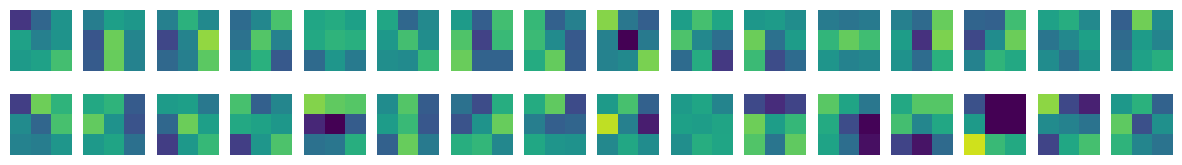

In [14]:
#32개의 커널을 16개씩 두줄로 출력해보기
fig, axs = plt.subplots(2, 16, figsize=(15,2))
for i in range(2):
  for j in range(16):
    axs[i, j].imshow(conv_weights[:,:,0,i*16 +j], vmin=-0.5, vmax=0.5)
    axs[i, j].axis('off')
plt.show()

In [15]:
#훈련하지 않은 합성곱 신경망
no_training_model = keras.Sequential()
no_training_model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu',
                                          padding='same', input_shape=(28,28,1)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
#이 모델의 첫 번쨰 층(합성곱 층)의 가중치를 저장
no_training_conv = no_training_model.layers[0]

print(no_training_conv.weights[0].shape)

(3, 3, 1, 32)


In [17]:
#평균과 표준편차(훈련된 모델에 비해 표준편차가 매우 작다)
no_training_weights = no_training_conv.weights[0].numpy()

print(no_training_weights.mean(), no_training_weights.std())

0.0075575477 0.08205484


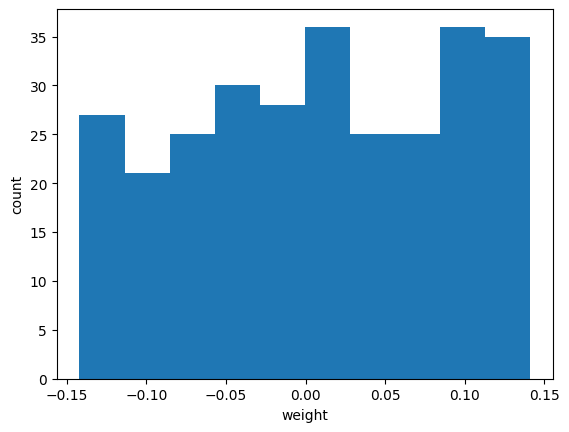

In [19]:
#히스토그램 그려보기
plt.hist(no_training_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

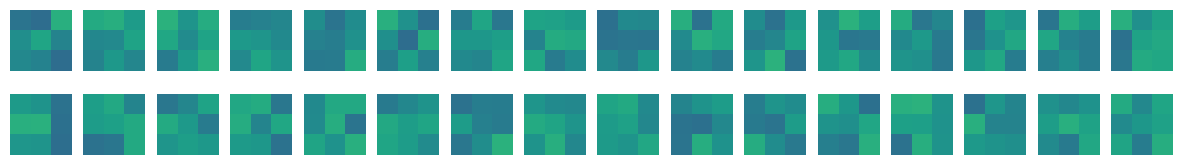

In [20]:
#층의 시각화(훈련되지 않은 모델이다)
fig, axs = plt.subplots(2, 16, figsize=(15,2))

for i in range(2):
    for j in range(16):
        axs[i, j].imshow(no_training_weights[:,:,0,i*16 + j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')

plt.show()

히스토그램으로 보았듯이 전체적으로 가중치가 밋밋하게 초기화됨.

훈련된 모델의 가중치와 비교해보면 합성곱 신경망이 패션 MNIST 데이터셋의 분류 정확도를 높이기 위해 유용한 패턴을 학습했다는 사실을 눈치챌수 있다.

## 함수형 API
합성곱 신경망의 학습을 시각화하는 두 번째 방법으로 합성곱 층에서 출력된 특성 맵을 그려본다.

이를 통해 입력 이미지를 신경망 층이 어떻게 바라보는지 엿볼 수 있다.

그전에 함수형 API를 알아보자.

지금까지는 Sequential 클래스를 사용했는데 이 클래스는 층을 차례대로 쌓은 모델을 만든다. 하지만 딥러닝에서는 좀 더 복잡한 모델이 많이 있는데 이런 경우에는 Sequential 보다 함수형 API를 사용한다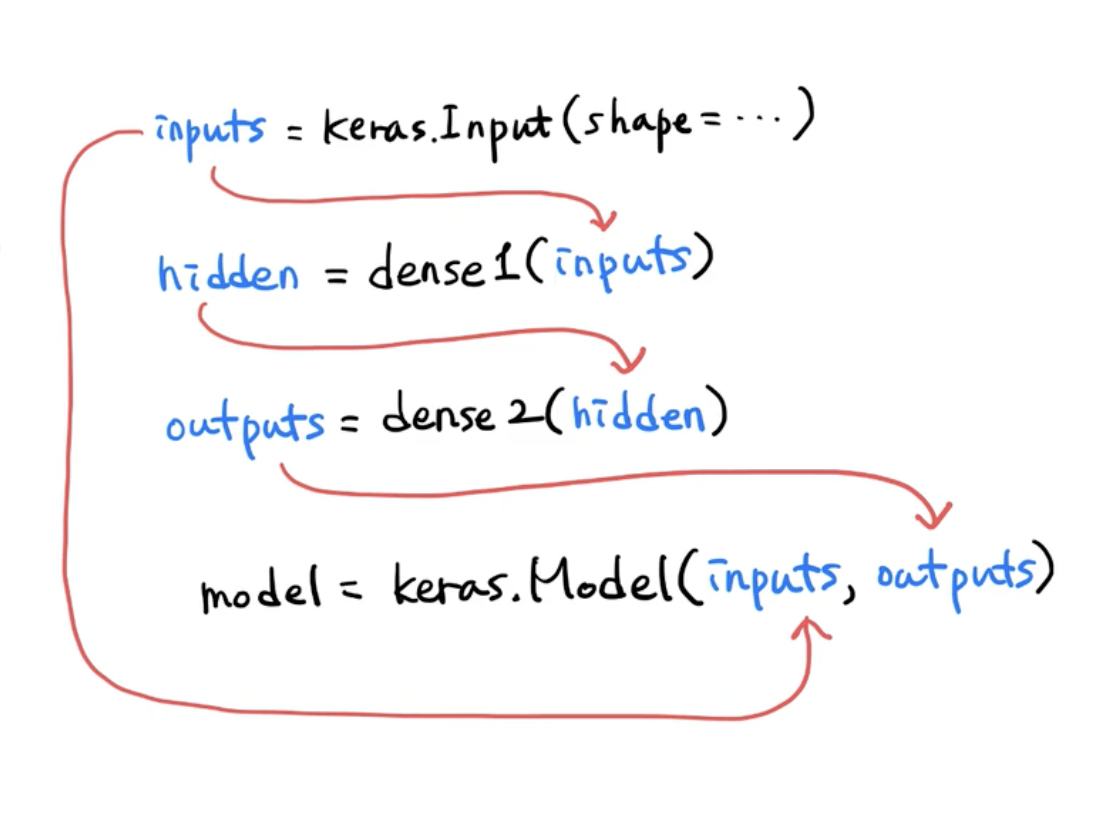

In [21]:
#7장에서 했던 완전연결신경망을 함수형 API로 구현해보괴
inputs = keras.Input(shape=(784,))
dense1 = keras.layers.Dense(100, activation='relu')
dense2 = keras.layers.Dense(10, activation='softmax')

In [22]:
#함수로 호출
hidden = dense1(inputs)
outputs = dense2(hidden)

In [23]:
#Model 클래스로 연결
func_model = keras.Model(inputs, outputs)

## 활성화 출력 얻기

특성 맵 시각화를 만드는데 함수형 APU가 필요한 이유?
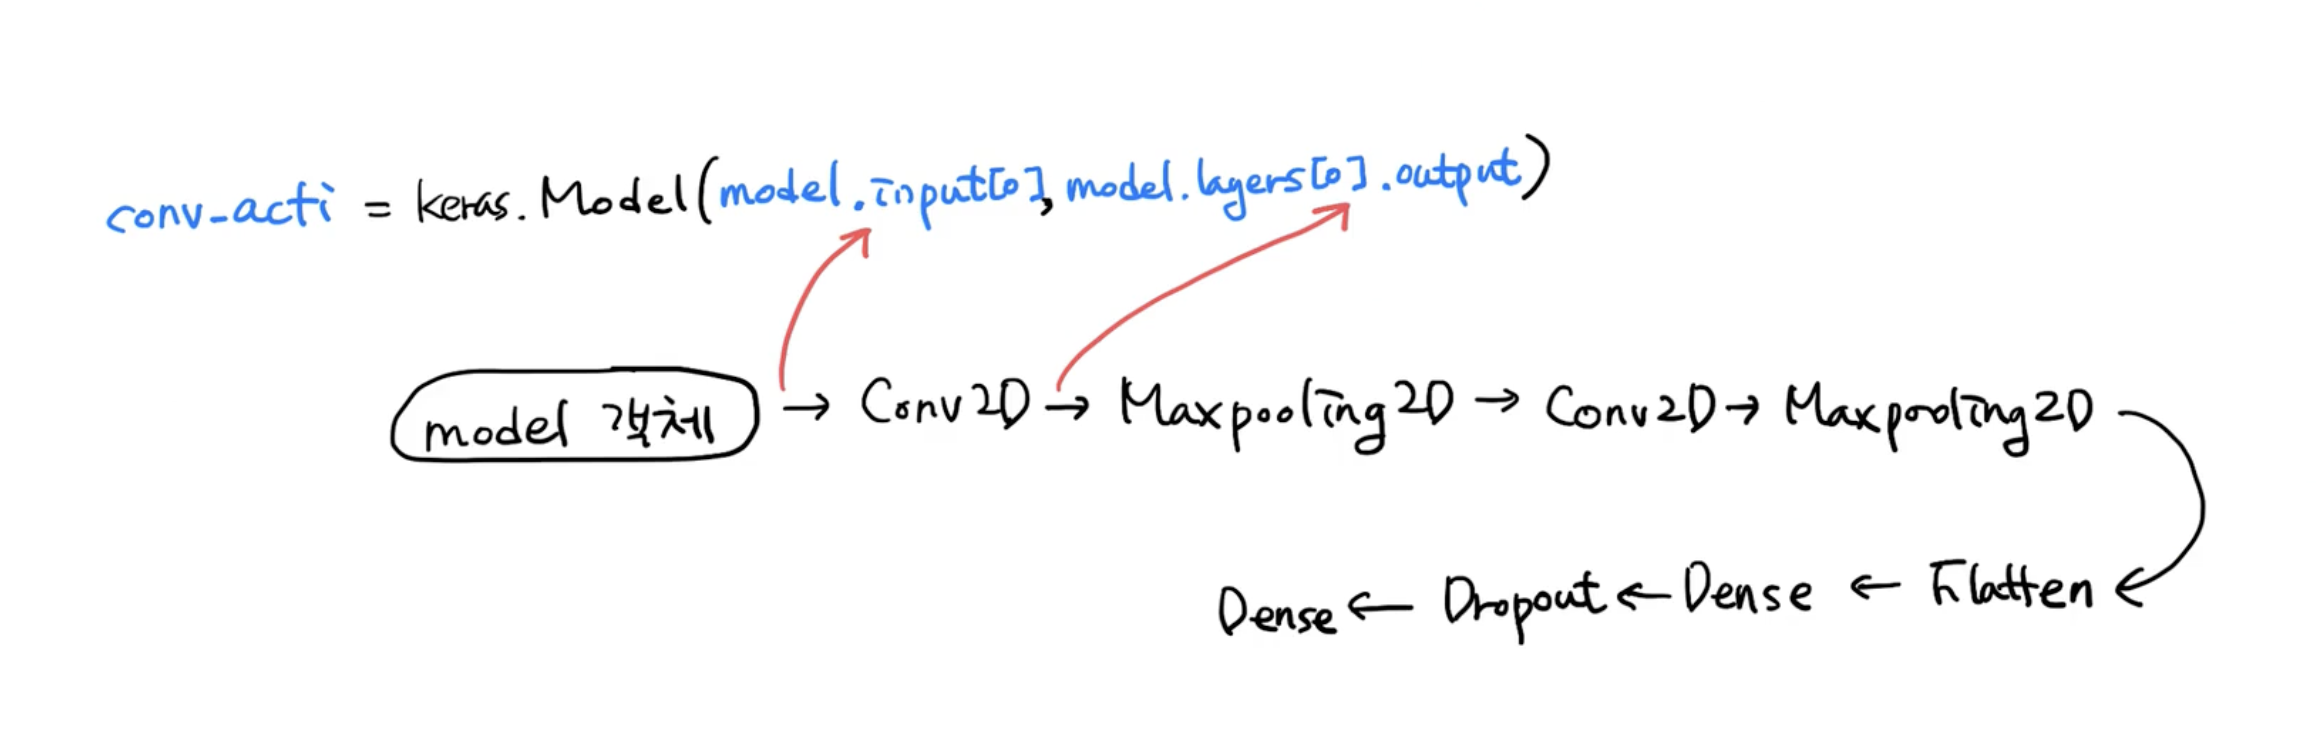

In [24]:
#model객체의 입력과 첫번째 Conv2D의 출력을 알수 있다면 이 둘을 연결하여 새로운 모델을 얻을 수 있지 않을까?
#입력얻기
print(model.inputs)

[<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=input_layer>]


In [25]:
#새로운 모델
conv_acti = keras.Model(model.inputs[0], model.layers[0].output)

## 첫 번째 특성 맵 시각화

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


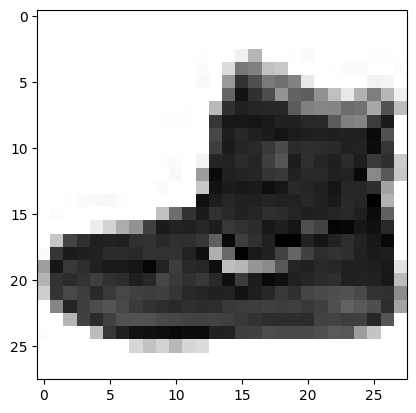

In [26]:
#훈련세트에 있는 첫번째 샘플 그려보기
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()
plt.imshow(train_input[0], cmap='gray_r')
plt.show()

In [29]:
#이 샘플을 conv_acti 모델에 주입하여 Conv2D 층이 만드는 특성 맵을 출력해보기
ankle_boot = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0
feature_maps = conv_acti.predict(ankle_boot)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


In [31]:
#특성맵 크기확인
print(feature_maps.shape)

(1, 28, 28, 32)


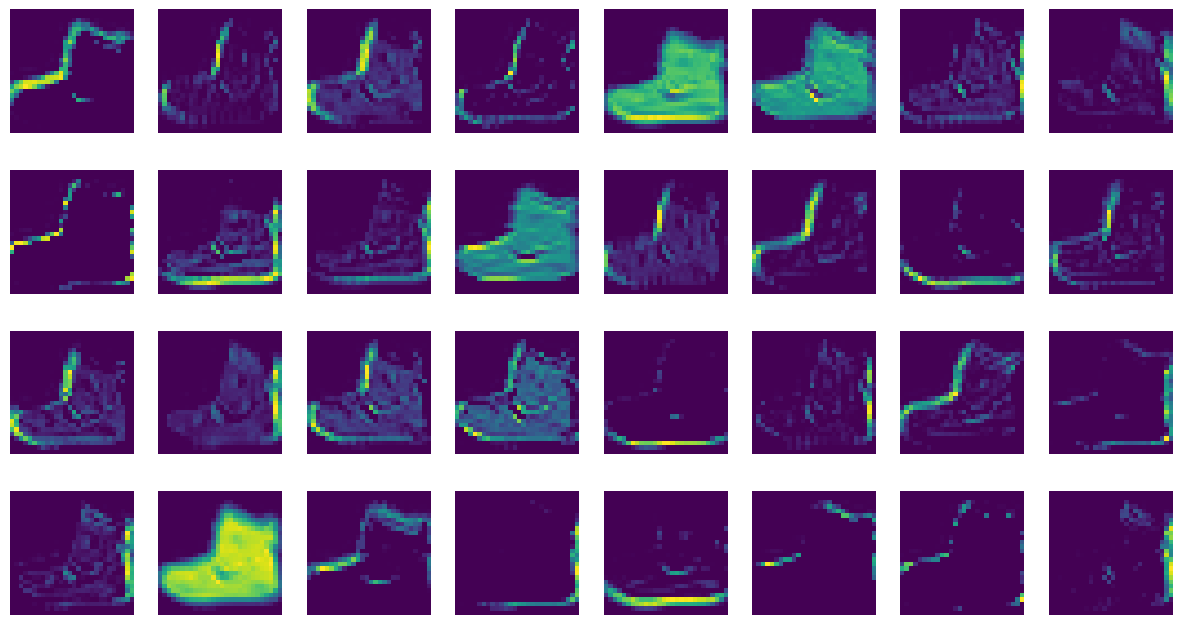

In [32]:
#특성맵 시각화
fig, axs = plt.subplots(4, 8, figsize=(15,8))

for i in range(4):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0,:,:,i*8 + j])
        axs[i, j].axis('off')

plt.show()

위 특성 맵은 32개의 필터로 인해 입력 이미지에서 강하게 활성화 된 부분을 보여준다.

## 두 번재 특성 맵 시각화
        

In [33]:
conv2_acti = keras.Model(model.inputs[0], model.layers[2].output)

In [34]:
#예측 메서드에 전달
feature_maps = conv2_acti.predict(ankle_boot)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


In [35]:
#특성맵 크기확인
print(feature_maps.shape)

(1, 14, 14, 64)


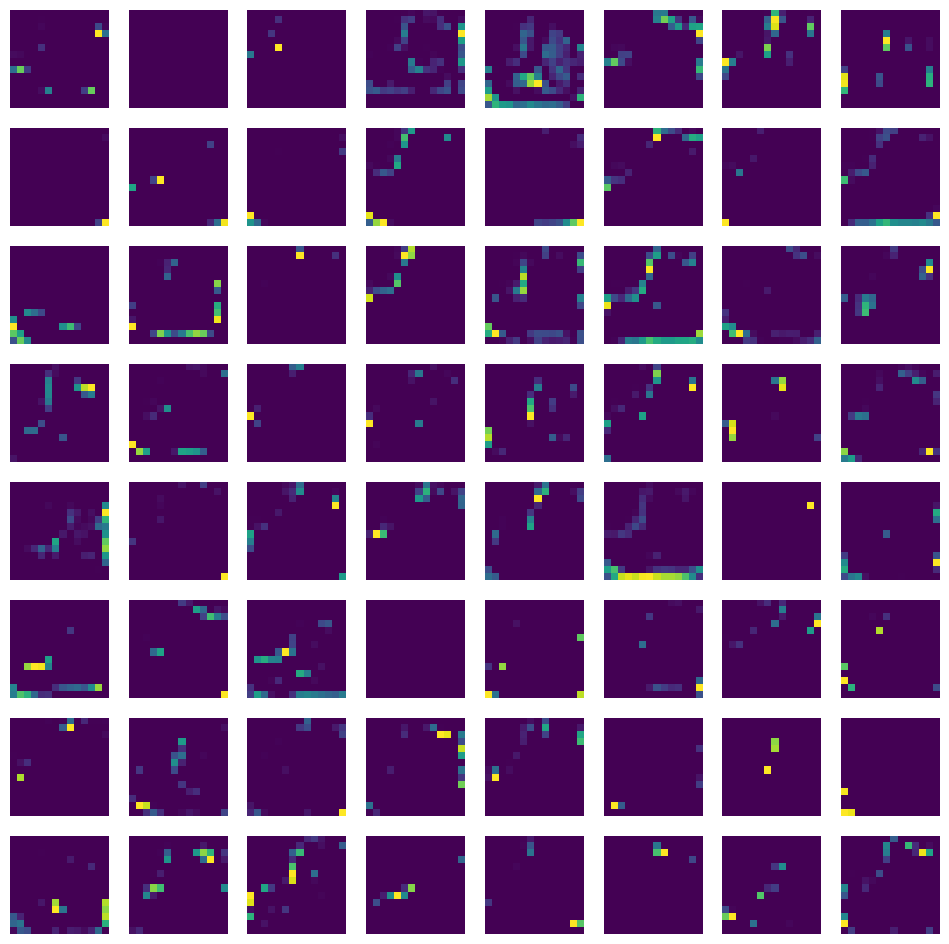

In [36]:
#특성 맵 시각화
fig, axs = plt.subplots(8, 8, figsize=(12,12))

for i in range(8):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0,:,:,i*8 + j])
        axs[i, j].axis('off')

plt.show()

첫 번쨰 특성맵 시각화랑 다르게 시각적 이해가 어려움.